# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("fifa_players.csv")
df.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


In [7]:
attacking_roles = ["ST", "CF", "LW", "RW"]
df_attackers = df[df["positions"].str.contains("|".join(attacking_roles))]
top20_attackers = df_attackers.sort_values(by="overall_rating", ascending=False).head(20)
top20_attackers[["name", "positions", "overall_rating", "finishing", "dribbling", "vision", "short_passing", "acceleration"]]
df_attackers.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
6,K. Mbappé,Kylian Mbappé,12/20/1998,20,152.40,73.0,"RW,ST,RM",France,88,95,...,78,62,38,88,82,70,86,34,34,32
7,S. Agüero,Sergio Leonel Agüero del Castillo,6/2/1988,30,172.72,69.9,ST,Argentina,89,89,...,83,65,24,92,83,83,90,30,20,12
9,E. Cavani,Edinson Roberto Cavani Gómez,2/14/1987,32,185.42,77.1,ST,Uruguay,89,89,...,79,84,48,93,77,85,82,52,45,39


C:\Users\heman\AppData\Local\Temp\ipykernel_165756\2609799677.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


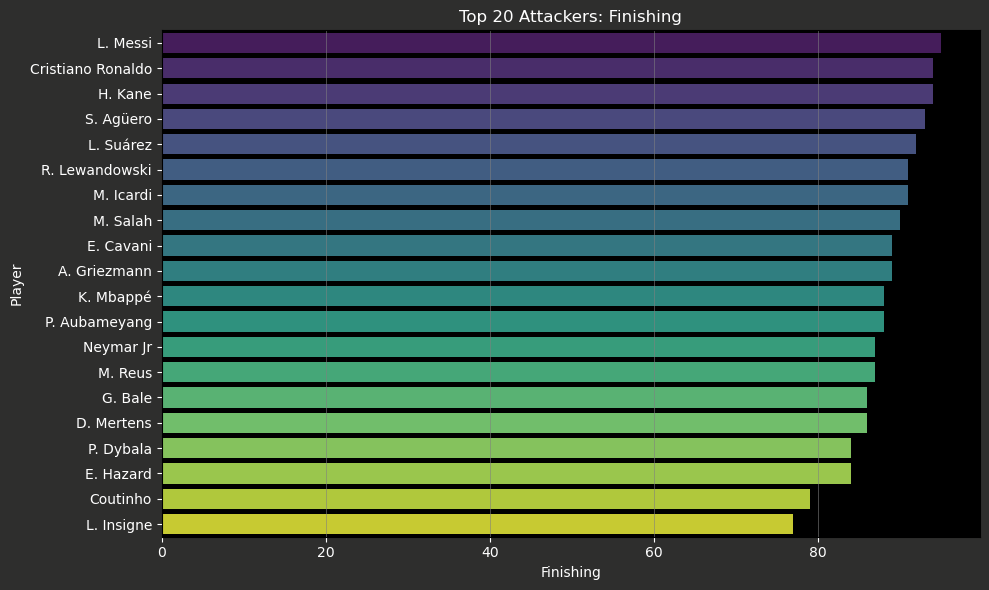

C:\Users\heman\AppData\Local\Temp\ipykernel_165756\2609799677.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


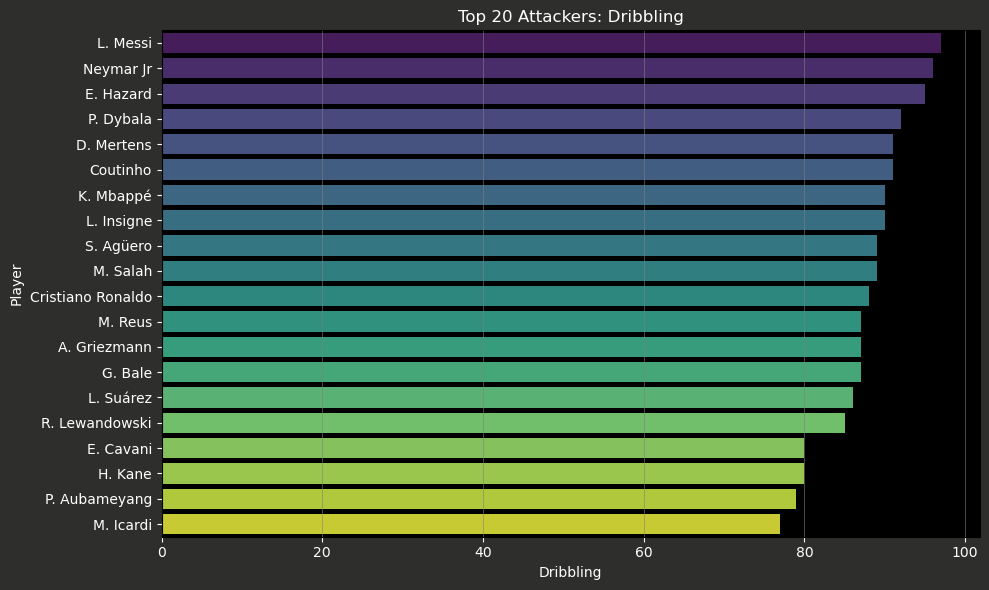

C:\Users\heman\AppData\Local\Temp\ipykernel_165756\2609799677.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


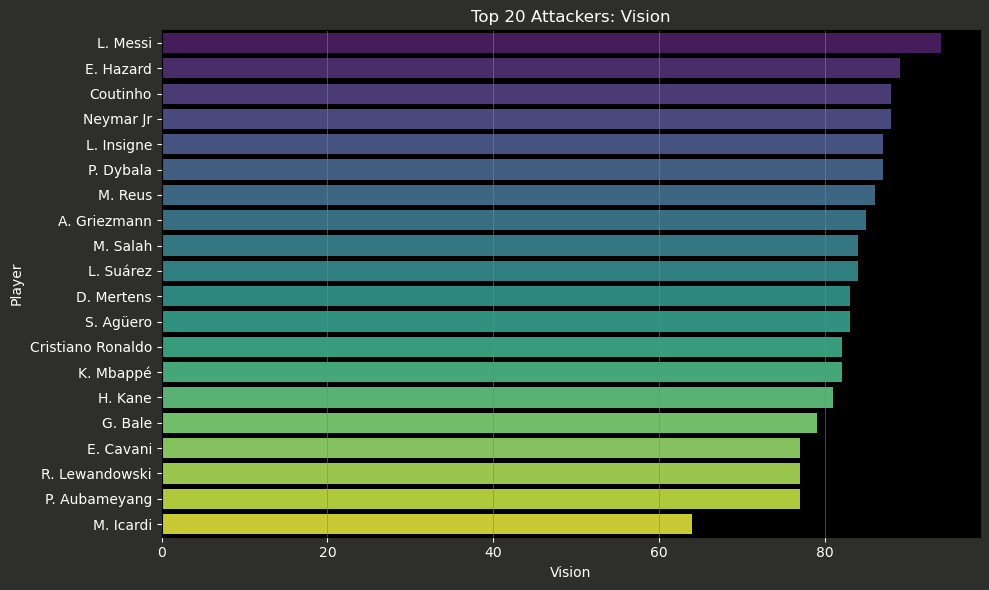

C:\Users\heman\AppData\Local\Temp\ipykernel_165756\2609799677.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


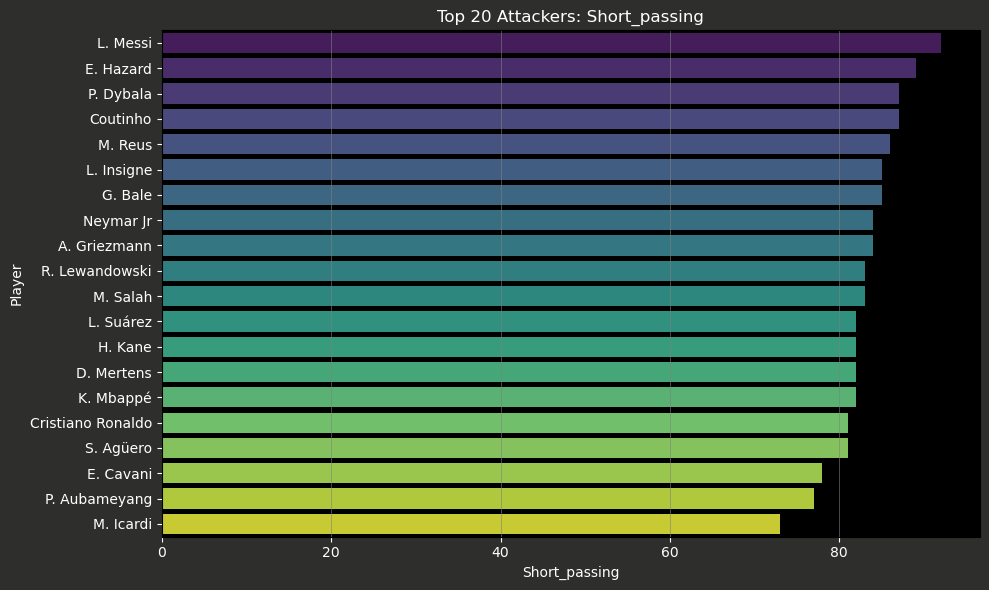

C:\Users\heman\AppData\Local\Temp\ipykernel_165756\2609799677.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


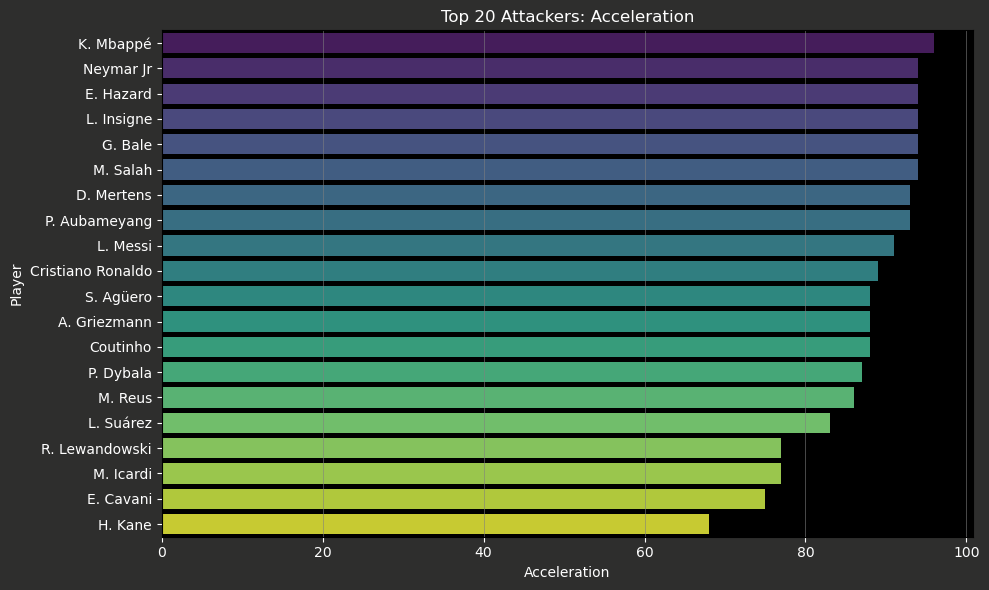

In [ ]:
features = ["finishing", "dribbling", "vision", "short_passing", "acceleration"]

for feat in features:
    fig, ax = plt.subplots(figsize=(10,6))


    plot_data = top20_attackers.sort_values(by=feat, ascending=False)

    sns.barplot(data=plot_data,x=feat,y="name",palette="viridis")

  
    fig.set_facecolor('#2e2e2d')
    ax.set_facecolor('black')
    ax.grid(True, axis='x', linestyle='-', linewidth=.4, color='gray')
    ax.set_title(f"Top 20 Attackers: {feat.capitalize()}", color='white')
    ax.set_xlabel(feat.capitalize(), color='white')
    ax.set_ylabel("Player", color='white')
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')

    plt.tight_layout()
    plt.show()

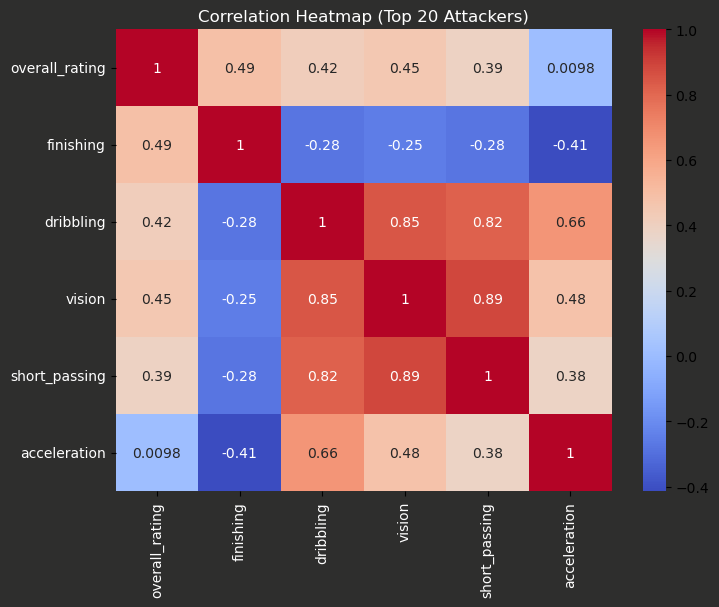

In [11]:
fig, ax = plt.subplots(figsize=(8,6))
corr = top20_attackers[["overall_rating"] + features].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", ax=ax)

fig.set_facecolor('#2e2e2d')
ax.set_facecolor('black')
ax.set_title("Correlation Heatmap (Top 20 Attackers)", color='white')
plt.yticks(color='white')
plt.xticks(color='white')
plt.show()


Conclusion:
From the analysis of the top 20 attackers (ST, CF, LW, RW), the features that show the strongest relationship with overall rating are dribbling, finishing, and vision. Short passing has some influence but not as strong, while acceleration shows the weakest connection. Overall, technical ability appears to play a bigger role in determining a player’s overall rating than physical speed.